# Physics Informed Neural Networks and Deep Operator Network for beginners

#### by [Francisco Periago](https://multisimo.com/fpe/)

### Experiment 4: training DeepONet algo to approximate the operator

$$
	\begin{array}{lcl}
		\mathcal{G:} & L^2(0,1) \times H^{-1}(0,1) & \rightarrow L^2(0,2) \\
		& (y^0, y^1) & \mapsto \mathcal{G}(y^0, y^1) := u
	\end{array}
$$
where $u$ is the **unique** control of minimal $L^2$-norm of the system


$$
\left\{\begin{array}{ll}
			y_{tt}- y_{xx}=0, & \text{in } (0, 1)\times (0, 2) \\
			y(x,0)=y^0(x), & \text{on } (0, 1) \\
			y_t(x,0)=y^1(x) & \text{on } (0, 1)  \\
			y(0,t)=0, & \text{on }  \left(0,2\right) \\
			y(1,t)=u(t) & \text{on }   \left(0,2\right) \\
			y(x,2) = y_t(x,2)=0, & \text{on } (0, 1).
		\end{array}	
		\right.
$$

In [1]:
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt

Using backend: tensorflow.compat.v1
Other supported backends: tensorflow, pytorch, jax, paddle.
paddle supports more examples now and is recommended.


Instructions for updating:
non-resource variables are not supported in the long term



Parameters

In [2]:
ITERATIONS = 20000

First, we load the data files

In [3]:
X_train = np.load("../data/X_train_linear_wave.npy") 
X_test = np.load("../data/X_test_linear_wave.npy") 
y_train = np.load("../data/y_train_linear_wave.npy") 
y_test = np.load("../data/y_test_linear_wave.npy") 
X_train_input_dimension = X_train.shape[1] - 1

### Let's analyse the structure of the data. 
A data point is a triplet $((y^0, y^1), t, \mathcal{G}(y^0, y^1)(t))$. Moreover, a specific input $(y^0, y^1)$ appears in multiple data points with different values of $t$. In our case, we have sampled $100$ initial conditions on $51$ sensor points. Thus, the enconding operator maps $(y^0, y^1)$ onto a vector $y^{\text{initial}}$ of $51\times 2 = 102$ components. The first $51$ components correspond to $y^0$ and the remaining to $y^1$.

As for discretization of the time variable $t$, we have considered n_sensors_t = 101. Accordingly, we repeat each $y^{\text{initial}}$ $101$ times. As a consequence, X_train is a matrix of size (n_sensors_t $\times$ n_functions) $\times 103  = 10100 \times 103$, the last column collecting $100$ times n_sensors_t.

Finally, y_train is a column matrix which accounts for the control at the discrete times.

Precisely, 
$$
	 X_{train} = \left[\begin{array}{cccc}
		y^{\text{initial}}_{1,1} & \cdots & y^{\text{initial}}_{1,2m} & t_1 \\
		\cdots & \cdots & \cdots & 	\cdots \\
		y^{\text{initial}}_{1,1} & \cdots & y^{\text{initial}}_{1,2m} & t_{\ell} \\
		\hline 
		\cdots & \cdots & \cdots & 	\cdots \\
		\cdots & \cdots & \cdots & 	\cdots \\
		\hline
		y^{\text{initial}}_{N,1} & \cdots & y^{\text{initial}}_{N,2m} & t_1 \\
		\cdots & \cdots & \cdots & 	\cdots \\
		y^{\text{initial}}_{N,1} & \cdots & y^{\text{initial}}_{N,2m} & t_{\ell} \\
	\end{array}		
	\right], \qquad 
    	y_{train} = \left[\begin{array}{c}
		 u_1(t_1) \\
			\cdots \\
		 u_1(t_\ell) \\
		\hline 
		 	\cdots \\
		 	\cdots \\
		\hline
		u_N(t_{1}) \\
		\cdots \\
		u_N(t_{\ell}) \\
	\end{array}		
	\right]
$$

For implementation purposes, X_train and X_test are split into tuples, where the last column is separated from the remaining features.

In [4]:
X_train = (X_train[:, :-1], X_train[:, -1:])
X_test = (X_test[:, :-1], X_test[:, -1:])

We are now ready to define the data

In [5]:
data = dde.data.Triple(
            X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test
        )

Next, we define the architecture of the  DeepONet, which follows the structure

<img src="architecture.png.PNG" alt="deeponet" width="600"/>



In [6]:
m = X_train_input_dimension
dim_t = 1  # input dimension of the trunk
p = 10 # output dimension of the branch and trunk nets
net = dde.nn.DeepONet(
    [m, 40, p],  # dimensions of the fully connected branch net. Just one hidden layer of 40 neurons
    [dim_t, 40, p],  # dimensions of the fully connected trunk net. Just one hidden layer of 40 neurons
    "relu",          # relu for both branch and trunk
    "Glorot normal",  # initialization of parameters
    )

Let's continue with the model

In [7]:
model = dde.Model(data, net)
model.compile("adam", lr=0.001)

Compiling model...
Building DeepONet...
'build' took 0.094078 s



c:\Users\Periagol\anaconda3\envs\deeponetcontrol\lib\site-packages\deepxde\nn\tensorflow_compat_v1\deeponet.py:367: UserWarning: `tf.layers.dense` is deprecated and will be removed in a future version. Please use `tf.keras.layers.Dense` instead.
  return tf.layers.dense(


'compile' took 0.301075 s



It's time for training

Training model...

Step      Train loss    Test loss     Test metric
0         [3.74e-01]    [3.87e-01]    []  
1000      [2.00e-02]    [2.42e-02]    []  
2000      [1.73e-02]    [2.16e-02]    []  
3000      [1.25e-02]    [1.93e-02]    []  
4000      [8.48e-03]    [1.49e-02]    []  
5000      [7.42e-03]    [1.41e-02]    []  
6000      [7.85e-03]    [1.39e-02]    []  
7000      [6.38e-03]    [1.28e-02]    []  
8000      [6.16e-03]    [1.20e-02]    []  
9000      [6.22e-03]    [1.16e-02]    []  
10000     [5.95e-03]    [1.12e-02]    []  
11000     [6.06e-03]    [1.14e-02]    []  
12000     [6.07e-03]    [1.14e-02]    []  
13000     [5.61e-03]    [1.07e-02]    []  
14000     [5.59e-03]    [1.06e-02]    []  
15000     [5.50e-03]    [1.04e-02]    []  
16000     [5.36e-03]    [1.02e-02]    []  
17000     [5.33e-03]    [1.02e-02]    []  
18000     [5.26e-03]    [1.00e-02]    []  
19000     [5.22e-03]    [9.94e-03]    []  
20000     [5.19e-03]    [9.84e-03]    []  

Best model at step 20000:
 

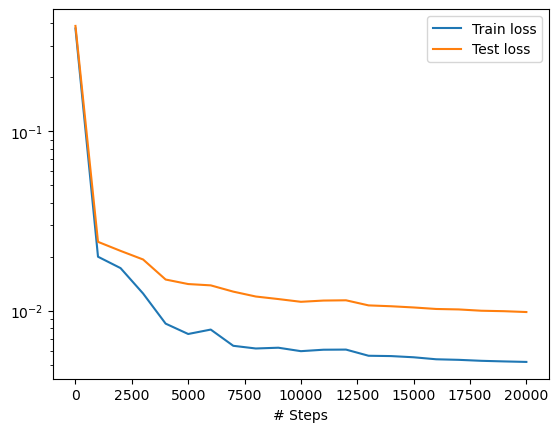

In [8]:
losshistory, train_state = model.train(iterations=ITERATIONS)
dde.saveplot(losshistory, train_state, issave=True, isplot=True)

Making predictions and comparing with an exact solution

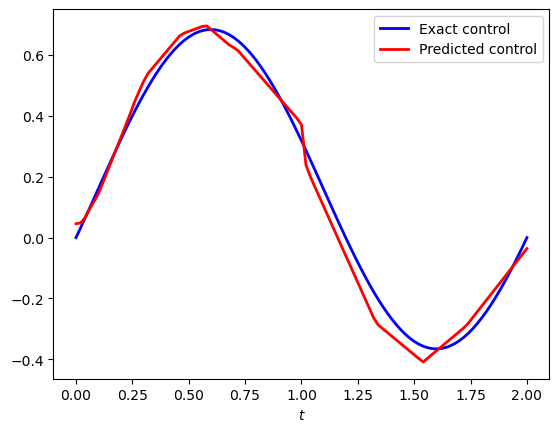

error = 0.09590888225562721


In [9]:
n_sensores_x = 51
x = np.linspace(0, 1, n_sensores_x)
t = np.linspace(0, 2, 2 * n_sensores_x - 1)
y0 = np.sin(np.pi * x)
y1 = np.sin(np.pi * x)
y_initial = np.concatenate((y0, y1))
exact_control = np.piecewise(
    t,
    [t <= 1, t > 1],
    [
        lambda t: 0.5 * np.sin(np.pi * (1 - t))
        - (0.5 / np.pi) * (np.cos(np.pi) - np.cos(np.pi * (1 - t))),
        lambda t: -0.5 * np.sin(np.pi * (t - 1))
        - (0.5 / np.pi) * (np.cos(np.pi) - np.cos(np.pi * (t - 1))),
    ],
)
predict_control = np.ravel(
    model.predict((np.tile(y_initial, (len(t), 1)), t[:, None]))
)

fig, ax = plt.subplots()
ax.plot(t, exact_control, "-b", linewidth=2, label="Exact control")
ax.plot(t, predict_control, "-r", linewidth=2, label="Predicted control")
ax.set_xlabel("$t$")
ax.legend()
#plt.savefig(predict_plot_file)
#plt.close(fig)
plt.show()
error = dde.metrics.l2_relative_error(exact_control, predict_control)
print(f"error = {error}")